### Date: 2025-07-12

In [1]:
%load_ext autoreload
%autoreload 2
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS

import kuaizi
from kuaizi.display import display_single
kuaizi.set_env(project='JWST', name='', data_dir='/scratch/gpfs/JENNYG/jiaxuanl/Data')
kuaizi.set_matplotlib(style='JL', usetex=True, fontsize=18, figsize=(7, 5), dpi=90)

sys.path.append('/home/jiaxuanl/Research/SALAD/script/')
from display import show_image_wcs
from catalog import SatCandidate

sys.path.append('/home/jiaxuanl/Research/SBF/src/')
from SBF.masking import make_mask
from SBF.sbf import fit_sersic, calc_phys_thresh_absmag, sbf_monte_carlo, sbf_color_rv, dustmap, ext_coeff
from SBF.display import plot_SBF_all, show_D_meas
from SBF.sbf import SBFMonteCarloResults

sys.path.append('/home/jiaxuanl/Research/Packages/pymfit/')
import pymfit

In [391]:
name = 'dw_1e7.0_35Mpc_0.4Gyr_F158'
json_file = '/home/jiaxuanl/Research/Rosesim/data/Roman_sbf_par.json'
sat = SatCandidate.read_json(name, json_file)

A_extinct = {"F158": 0, 'F129': 0}

os.chdir(f'/scratch/gpfs/JENNYG/jiaxuanl/Data/SBF/Rosesim/dw_1e7.0_35Mpc_0.4Gyr')

## Load Data

Image shape: 909
Bkg shape: 727
seeing FWHM: 0.130 arcsec


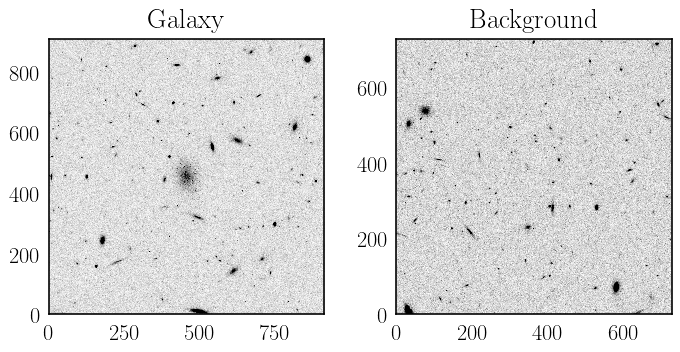

In [392]:
sat = SatCandidate.read_json(name, json_file)
sat.host_dist = sat.distance

# Add default params relevant to SBF, then you can tune these params in the json file by hand
if not hasattr(sat, 'cirrus'):
    sat.cirrus = False
if not hasattr(sat, 'sersic_mask_kwargs'):
    sat.sersic_mask_kwargs = {'cutsize': 350, 'delta_pos': 5, 'thresh': 3, "grow_sig": 2, 
                              "grow_obj": 2, "obj_rmin": 10, "seg_rmin": 10, "backsize": 15, 'sub_local_bkg': False}
if not hasattr(sat, 'sersic_init_params'):
    sat.sersic_init_params = {'PA': [120, 0, 180], 'ell': [0.3, 0, 0.9], 'n': [0.8, 0.3, 2]}
if not hasattr(sat, 'use_nonpar_model'):
    sat.use_nonpar_model = False
sat.non_par_params = {"shape": "square", "n_seeing": 6}
if not hasattr(sat, 'corr_noise'):
    sat.corr_noise = True # For Euclid
if not hasattr(sat, 'sbf_mask_kwargs'):
    sat.sbf_mask_kwargs = {'seg_rmin': 0, 'obj_rmin': 0, 'grow_sig': 3.0, 'grow_obj': 3.0, 
                           'phys_thresh': True, 'M_abs': -4.2, "backsize": 30, "backffrac": 0.3}
if not hasattr(sat, 'sbf_meas_kwargs'):
    sat.sbf_meas_kwargs = {'k1': [0.05, 0.1], 'k2': [0.45, 0.5], 'gal_outer': [0.3, 0.4], 'gal_inner': [2, 2], 
                           'n_trials': 40, 'n_bkgs': 3, 'cut_n_reff': 2.5, 'num_radial_bins': 35}
# sat.non_par_params = {"shape": "square", "n_seeing": 10} # 10 for square, 8 for disk
# sat.cirrus_mask_params = {"a": 1, "b": 0.9, "theta": 0,  "r": 50, "n_seeing": 5}
sat.write_json(json_file)

sat = SatCandidate.read_json(name, json_file)
zp = sat.zp
pixel_scale = sat.pixel_scale
sbf_filt = sat.sbf_filt
followup = sat.followup

# Load galaxy Image
hdu = fits.open(f'./SBF_cutout/{name}_{followup}-{sbf_filt}.fits')
img = hdu['IMAGE'].data
img_w = WCS(hdu['IMAGE'].header)
var = hdu['VARIANCE'].data
psf = hdu['PSF'].data
psf /= psf.sum()
psf_samp = hdu['PSF'].header['PSF_SAMP']
s = img.shape[0]
print('Image shape:', s)

# Load Background Image
bkg_hdu = fits.open(f'./SBF_cutout/{name}_{followup}-{sbf_filt}_bkg.fits')
bkg_w = WCS(bkg_hdu['IMAGE'].header)
bkg_img = bkg_hdu['IMAGE'].data
bkg_img = np.nan_to_num(bkg_img, 0.0)
print('Bkg shape:', bkg_img.shape[0])

fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(8, 4), dpi=90)
show_image_wcs(img, ax=ax1, fig=fig, percl=99.7)
show_image_wcs(bkg_img, ax=ax2, fig=fig, percl=99.7)
ax1.set_title('Galaxy')
ax2.set_title('Background')
plt.tight_layout()

from scipy.ndimage.filters import median_filter
from SBF.utils import calc_PSF_FWHM
seeing = calc_PSF_FWHM({sat.sbf_filt: psf})[sat.sbf_filt] * sat.pixel_scale * psf_samp
print(f'seeing FWHM: {seeing:.3f} arcsec')

# 0: cirrus

In [393]:
# for a cirrus heavy field, we first construct a cirrus model and subtract it from the image
sat = SatCandidate.read_json(name, json_file)
if sat.cirrus:
    import sep
    mask = np.zeros_like(img, dtype=bool)
    sep.mask_ellipse(mask, mask.shape[1]//2, mask.shape[0]//2, a=sat.cirrus_mask_params['a'], 
                     b=sat.cirrus_mask_params['b'], theta=np.deg2rad(sat.cirrus_mask_params['theta']), 
                     r=sat.cirrus_mask_params['r'])
    filter_size = int(sat.cirrus_mask_params['n_seeing'] * seeing / sat.pixel_scale)
    bkg = sep.Background(img.byteswap().newbyteorder(), mask=mask, bw=filter_size, bh=filter_size, fw=3, fh=3)

    fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(10, 3))
    display_single(img * ~mask, ax=ax1)
    display_single(bkg.back(), ax=ax2)
    display_single(img - bkg.back(), ax=ax3)

In [394]:
if sat.cirrus: 
    print('Subtract cirrus model')
    img -= bkg.back()

In [395]:
# Also subtract cirrus in the background field
sat = SatCandidate.read_json(name, json_file)
if sat.cirrus:
    import sep
    mask = np.zeros_like(bkg_img, dtype=bool)
    sep.mask_ellipse(mask, mask.shape[1]//2, mask.shape[0]//2, a=1, b=1, theta=0, r=10)
    filter_size = int(sat.cirrus_mask_params['n_seeing'] * seeing / sat.pixel_scale)
    bkg = sep.Background(bkg_img.byteswap().newbyteorder(), mask=mask, bw=filter_size, bh=filter_size, fw=3, fh=3)

    fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(10, 3))
    display_single(bkg_img * ~mask, ax=ax1)
    display_single(bkg.back(), ax=ax2)
    display_single(bkg_img - bkg.back(), ax=ax3)

In [396]:
if sat.cirrus:
    print('Subtract cirrus model')
    bkg_img -= bkg.back()

## 1. Sersic fitting to remove smooth component

PA: SMA points up is zero. left is 90. down is 180. 

In [397]:
hsc_mask = np.zeros_like(img, dtype=bool)

In [398]:
# hsc_mask = img == -1.0751108e+01
# hsc_mask = np.isnan(img)
# img = np.nan_to_num(img, 0.0)
# from astropy.convolution import convolve_fft, Gaussian2DKernel
# temp = convolve_fft(hsc_mask, Gaussian2DKernel(10))
# hsc_mask = (temp > 1e-3)

dw_1e7.0_35Mpc_0.4Gyr_F158
0.04711082577705383


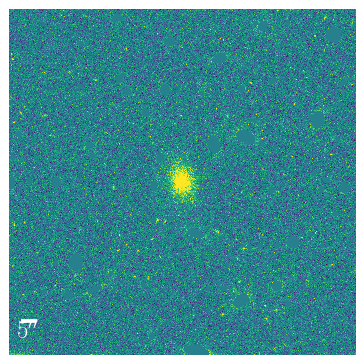

In [399]:
sat = SatCandidate.read_json(name, json_file)
print(sat.name)
if sat.sersic_mask_kwargs['sub_local_bkg']:
    import sep
    box = int(15 * seeing / sat.pixel_scale)
    bkg = sep.Background(img.byteswap().newbyteorder(), bw=box, bh=box)
    img_det = img - bkg.back()
    print('sub_local_bkg = True')
else:
    img_det = img
sersic = fit_sersic(name, img_det, hsc_mask=hsc_mask, var=var, psf=psf, 
                    filt=sat.sbf_filt, 
                    mask_kwargs=sat.sersic_mask_kwargs, 
                    sersic_init_params=sat.sersic_init_params, 
                    fit=False)

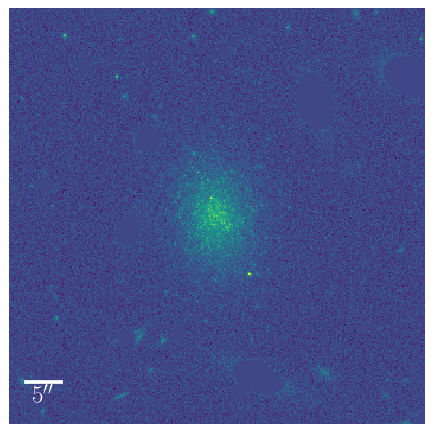

In [400]:
%matplotlib inline
hdu = fits.open(f'./sersic/img_{name}.fits')
display_single(hdu[0].data * (~(hdu[1].data.astype(bool))), scale='linear', xsize=6, ysize=6);

In [401]:
sat = SatCandidate.read_json(name, json_file)
sersic, _ = fit_sersic(name, img_det, hsc_mask=hsc_mask, var=var, psf=psf, include_psf=False,
                    filt=sat.sbf_filt, 
                    mask_kwargs=sat.sersic_mask_kwargs, 
                    sersic_init_params=sat.sersic_init_params, 
                    fit=True, quiet=False)

0.04711082577705383
Fitting Sersic profile for dw_1e7.0_35Mpc_0.4Gyr_F158 in F158-band ...
	Image file = ./sersic/img_dw_1e7.0_35Mpc_0.4Gyr_F158.fits[0]
	configuration file = ./sersic/config_dw_1e7.0_35Mpc_0.4Gyr_F158.txt
	noise image = ./sersic/img_dw_1e7.0_35Mpc_0.4Gyr_F158.fits[2]
	mask image = ./sersic/img_dw_1e7.0_35Mpc_0.4Gyr_F158.fits[1]
	output best-fit parameter file = ./sersic/dw_1e7.0_35Mpc_0.4Gyr_F158_F158.dat
Reading data image ("./sersic/img_dw_1e7.0_35Mpc_0.4Gyr_F158.fits[0]") ...
naxis1 [# pixels/row] = 351, naxis2 [# pixels/col] = 351; nPixels_tot = 123201
Reading mask image ("./sersic/img_dw_1e7.0_35Mpc_0.4Gyr_F158.fits[1]") ...
Reading noise image ("./sersic/img_dw_1e7.0_35Mpc_0.4Gyr_F158.fits[2]") ...
* No PSF image supplied -- no image convolution will be done!
ModelObject::AddMaskVector -- treating zero-valued pixels as good ...
Function: Sersic
7 total parameters
Model Object: 123201 data values (pixels)
ModelObject: mask vector applied to weight vector. (118538 

In [402]:
sat.ra, sat.dec, sat.zp

(150.1049, 2.2741, 25.265227862373404)

m_F158 18.253 mag
reff_F158 3.996938 arcsec


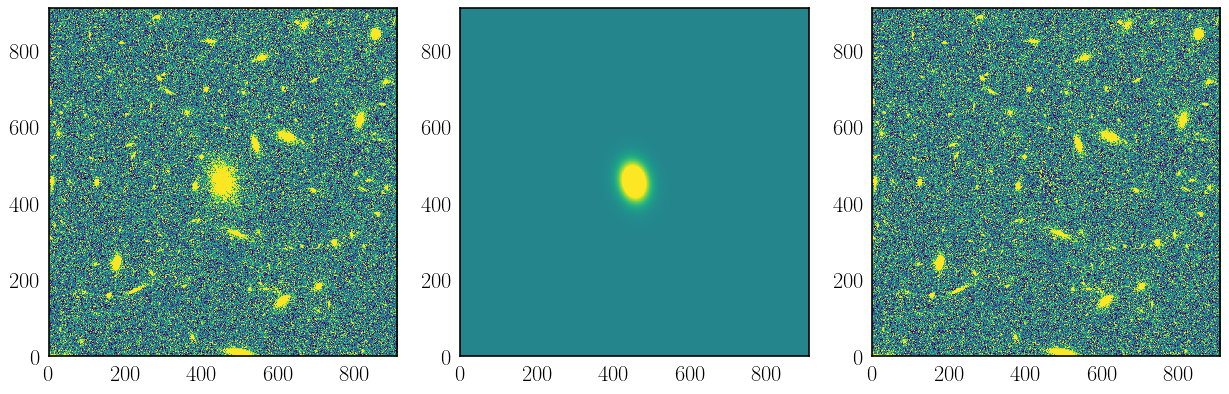

In [403]:
bestfit = pymfit.Sersic(sersic, pixscale=sat.pixel_scale, zpt=sat.zp) # Realize the Sersic model to an array
f_model_real = bestfit.array(img.shape)
print(f'm_{sat.sbf_filt}', np.round(bestfit.m_tot, 3) - A_extinct[sat.sbf_filt], 'mag')
print(f'reff_{sat.sbf_filt}', bestfit.r_e * sat.pixel_scale, 'arcsec')

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
_, _, scale = show_image_wcs(img, fig=fig, ax=axes[0], percl=95.5, cmap='viridis')
show_image_wcs(f_model_real, fig=fig, ax=axes[1], scale_args=scale, cmap='viridis')
show_image_wcs(img - f_model_real, fig=fig, ax=axes[2], scale_args=scale, cmap='viridis')
plt.tight_layout()

## Step2.1: SEP background model: Kim & Lee median filter method

In [404]:
sat = SatCandidate.read_json(name, json_file)
if sat.use_nonpar_model:
    from skimage.morphology import disk, square
    from skimage.filters import median
    sat = SatCandidate.read_json(name, json_file)
    if sat.use_nonpar_model:
        shape = sat.non_par_params.get('shape', 'square')
        n_seeing = sat.non_par_params.get('n_seeing', 10)
        print(f'shape = {shape}, n_seeing = {n_seeing}, seeing = {seeing:.3f} arcsec')
        if shape == 'square':
            filter_size = int(n_seeing * seeing / sat.pixel_scale)
            smooth_img = median_filter(img, size=(filter_size, filter_size))
            print(f'Median filtering with square({filter_size})')
        elif shape == 'disk':
            filter_size = int(n_seeing * seeing / sat.pixel_scale)
            smooth_img = median(img, disk(filter_size))
            print(f'Median filtering with disk({filter_size})')
    f_model_real = smooth_img
    f_model_real[f_model_real < 1e-8] = 1e-8

In [405]:
if sat.use_nonpar_model:
    fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(12, 5))
    ax1.imshow(f_model_real)
    ax1.axis('off')
    ax2 = display_single(img - f_model_real, ax=ax2)
    from display import show_image_wcs
    show_image_wcs(f_model_real, ax=ax1, fig=fig, percl=99.95)
    show_image_wcs(img - f_model_real, ax=ax2, fig=fig, percl=98)
    plt.tight_layout()

In [406]:
if sat.use_nonpar_model:
    sersic = pymfit.read_results(f'./sersic/{sat.name}_{sat.sbf_filt}.dat')
    sersic['use_nonpar'] = 1
    sersic['PIXSCALE'] = sat.pixel_scale
    sersic['ZP'] = sat.zp

## Step 2.2 Derive noise power spectrum

In [407]:
sat = SatCandidate.read_json(name, json_file)
if sat.corr_noise:
    from SBF.utils import compute_power_spectrum, compute_azimuthal_average, compute_k_values
    from SBF.masking import make_mask
    from kuaizi.utils import img_cutout
    # Mask out all sources aggressively
    import sep
    f_noise = bkg_img.copy()
    msk, bkg = make_mask(f_noise, thresh=0.2, backsize=30, 
                         seg_rmin=0.0, obj_rmin=0.0, 
                         grow_sig=2.0, mask_thresh=1e-3, grow_obj=2.0,)
    if "VIS" in sat.sbf_filt:
        bkg = sep.Background(f_noise.byteswap().newbyteorder(), mask=msk, bw=128, bh=128)
    else:
        bkg = sep.Background(f_noise.byteswap().newbyteorder(), mask=msk, bw=36, bh=36)
    f_noise -= bkg.back()

    if "VIS" in sat.sbf_filt:
        # Make mask
        noise_mask1, bkg = make_mask(f_noise, thresh=0.1, backsize=25, 
                             seg_rmin=0.0, obj_rmin=0.0, 
                             grow_sig=2, mask_thresh=1e-3, grow_obj=0.5,)
        noise_mask2, bkg = make_mask(f_noise * (~noise_mask1), mask=noise_mask1, thresh=0.4, backsize=15, 
                             seg_rmin=0.0, obj_rmin=0.0, 
                             grow_sig=2.0, mask_thresh=1e-3, grow_obj=1.0,)
    else:
        # Make mask
        noise_mask1, bkg = make_mask(f_noise, thresh=0.1, backsize=15, 
                             seg_rmin=0.0, obj_rmin=0.0, 
                             grow_sig=0.5, mask_thresh=1e-3, grow_obj=0.5,)
        noise_mask2, bkg = make_mask(f_noise * (~noise_mask1), mask=noise_mask1, thresh=0.3, backsize=4, 
                             seg_rmin=0.0, obj_rmin=0.0, 
                             grow_sig=1.0, mask_thresh=1e-3, grow_obj=1.0,)
    
    noise_mask = ~(noise_mask1 | noise_mask2)
    noise_obs = f_noise * noise_mask
    display_single(noise_obs);

In [408]:
if sat.corr_noise:
    ########### Infer noise property from data ############
    # The empty region we found is noise_obs (already masked)
    noise_obs = f_noise * noise_mask
    s_noise = noise_obs.shape[0]
    
    # find an estimate for sigma_noise, emperically
    temp = noise_obs.copy()
    temp[temp == 0] = np.nan
    sigma_noise_obs = np.nanstd(temp)
    print('estimated sigma_noise =', sigma_noise_obs)
    
    # power spec of the empty region, i.e, |R_noise(k)|^2 in overleaf
    ps_noise_obs = compute_power_spectrum(noise_obs)
    # power spec of the noise mask, i.e., |N(k)|^2
    ps_mask_noise = compute_power_spectrum(noise_mask)
    
    # recover the power spec of the underlying noise
    fft_noise_obs = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(ps_noise_obs)))
    fft_mask_noise = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(ps_mask_noise)))
    temp = fft_noise_obs / fft_mask_noise
    
    # Now this is the recovered (underlying) noise power spectrum
    ps_noise_recov = np.abs(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(temp))))
    ps_noise_recov *= 1 / sigma_noise_obs**2 # normalize it
    ps_noise_recov *= s_noise**2
    rps_noise_recov = compute_azimuthal_average(ps_noise_recov)[1] 
    k_noise = compute_k_values(s_noise)

    plt.plot(k_noise, rps_noise_recov, label='data')

    ## fit the noise rps with Butterworth equation
    from scipy.optimize import curve_fit
    from scipy.interpolate import interp1d
    def fit_function(k, a, n, k0, sigma_noise_obs):
        return a * (1 + (k / k0)**(2 * n))**(-1)
    
    k_lim = (0.15, 0.55)
    flag = (k_noise < k_lim[1]) & (k_noise > k_lim[0])
    sigma = rps_noise_recov / 10
    param_noise, cov = curve_fit(fit_function, k_noise[flag], rps_noise_recov[flag], 
                            sigma=sigma[flag], absolute_sigma=False,
                            p0=[10, 1, 0.3, 0])
    param_noise[-1] = sigma_noise_obs
    print(param_noise)
    
    param_noise = dict(zip(['a', 'n', 'k0', 'sigma_noise'], param_noise))
    
    plt.plot(k_noise, rps_noise_recov, label='data')
    plt.plot(k_noise, fit_function(k_noise, *param_noise.values()), color='dimgray', ls='--', label='best fit')
    # plt.plot(k_noise, fit_function(k_noise, *[1.6, 3.2, 0.5, 1]), color='r', ls='--', label='lanczos3')
    plt.ylim(0, 4)
    plt.legend()

## Step 3: Mask for SBF measurement

> we now need a physical threshold for detection, which should correspond to an absolute magnitude. See Carlsten+19 Section 3.1.

In [409]:
sat = SatCandidate.read_json(name, json_file)
print('M_abs for masking:', sat.sbf_mask_kwargs['M_abs'])
print('Assumed host distance:', sat.host_dist, 'Mpc')

# bkg = sep.Background(img.byteswap().newbyteorder(), bw=128, bh=128)
img_det = img

thresh2 = calc_phys_thresh_absmag(M_abs=sat.sbf_mask_kwargs['M_abs'], 
                                  dist=sat.host_dist, 
                                  zp=sat.zp, 
                                  img=img_det, psf=psf, psf_samp=psf_samp
                                  )
print('Mask thresh:', thresh2)

# Do masking
obj_mask, _ = make_mask(img_det - f_model_real, psf=psf, thresh=thresh2, **sat.sbf_mask_kwargs)
bkg_mask, _ = make_mask(bkg_img, psf=psf, thresh=thresh2, **sat.sbf_mask_kwargs)

print('PSF**2 sum =', np.sum(psf**2) / psf_samp**2)

M_abs for masking: -6.25
Assumed host distance: 35 Mpc
0.035367004573345184
bkg rms 0.02357800304889679
Mask thresh: 0.030508397707545588
0.030508397707545588
0.030508397707545588
PSF**2 sum = 0.14752462449038808


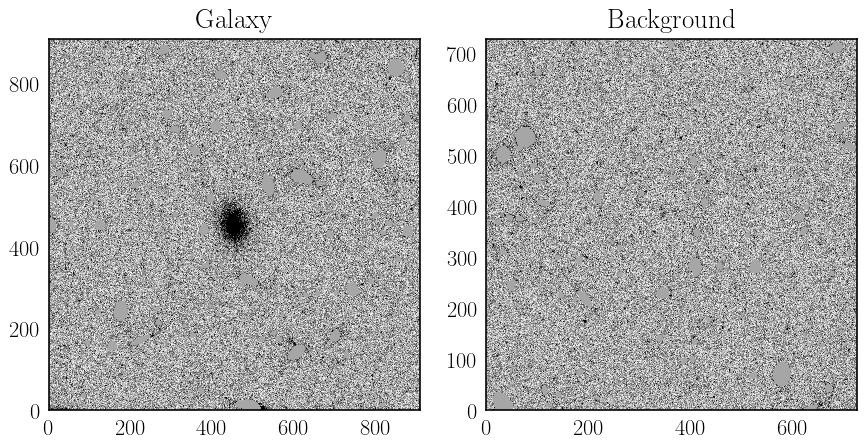

In [410]:
fig, [ax1, ax2] = plt.subplots(1, 2, figsize=(10, 5))
fig, _, scale = show_image_wcs((img) * ~obj_mask, ax=ax1, fig=fig, percl=99.5)
show_image_wcs(bkg_img * ~bkg_mask, ax=ax2, fig=fig, percl=99.5, scale_args=scale)
ax1.set_title('Galaxy')
ax2.set_title('Background')
plt.tight_layout()

In [411]:
# Write everything for SBF measurement into FITS file
# The comprehensive FITS file contains the galaxy image, mask, PSF, bkg img, bkg mask
hdulist = [fits.PrimaryHDU(),
        fits.ImageHDU(data=img, header=img_w.to_header(), name='Image'),
        fits.ImageHDU(data=obj_mask.astype(float), 
                      header=img_w.to_header(), name='Mask'),
        fits.ImageHDU(data=f_model_real, 
                      header=img_w.to_header(), name='Model'),
           fits.ImageHDU(data=psf, name='PSF', header=fits.Header({'PSF_SAMP': psf_samp})),
        fits.ImageHDU(data=bkg_img, header=bkg_w.to_header(), 
                      name='Background Image'),
        fits.ImageHDU(data=bkg_mask.astype(float), header=bkg_w.to_header(), 
                      name='Background Mask'),
        fits.BinTableHDU(Table({key: [value] for key, value in sersic.items()}), 
                         name='Sersic')]
if sat.corr_noise:
    hdulist += [fits.BinTableHDU(Table({key: [value] for key, value in param_noise.items()}), 
                     name='NOISE PARAM')]
hdulist = fits.HDUList(hdulist)
hdulist.writeto(f'./SBF_cutout/{name}_{sat.followup}-{sat.sbf_filt}_SBF.fits', overwrite=True)

In [412]:
psf_samp

0.25

In [413]:
from SBF.utils import interpsfex

In [414]:
# psf = interpsfex(sat.psf_file, np.array([20328.81246051, 23641.22264673])[None, :])[0]
# psf /= psf.sum()

In [415]:
# psf_hdu = fits.open('/scratch/gpfs/JENNYG/jiaxuanl/Data/Euclid/ERO-NGC6744/temp/dw1909m6341_VIS_PSF_samp_auto.fits')[0]
# psf = psf_hdu.data
# psf /= psf.sum()


---
## Step 4: SBF measurement

dw_1e7.0_35Mpc_0.4Gyr_F158


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:05<00:00,  8.91it/s]


Image shape: (109, 109)


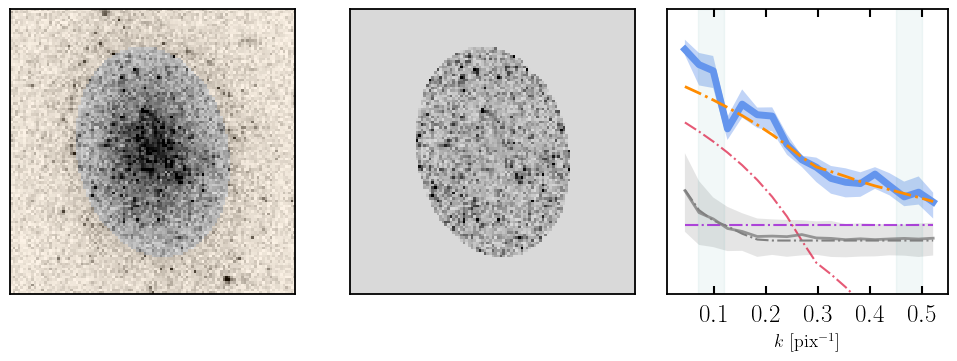

In [416]:
sbf_file = f'./SBF_cutout/{name}_{sat.followup}-{sat.sbf_filt}_SBF.fits'
sat = SatCandidate.read_json(name, json_file)
print(sat.name)

results = sbf_monte_carlo(sbf_file, no_MC=False, corr_noise=sat.corr_noise, **sat.sbf_meas_kwargs)
results.config = sat.__dict__

fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(results, sat, None, None, 
                                         percu=99.5, percl=2, show_psf=True, show_noise=True, show_bkgfit=True)

In [95]:
# results.to_pickle(f'./SBF_cutout/{name}_{sat.followup}-{sat.sbf_filt}_SBF_results.pickle')

In [96]:
# results = SBFMonteCarloResults().from_pickle(f'./SBF_cutout/{name}_{sat.followup}-{sat.sbf_filt}_SBF_results.pickle')

In [149]:
# np.median(results.f_sbf_bkgs), np.median(results.f_sbf_gals) # samp = auto, official psfex model

In [417]:
# Calculate distance
sat = SatCandidate.read_json(name, json_file)
n_ = 10000

f_sbf_meas = results.f_sbf_gals - results.f_sbf_bkgs
f_sbf = np.random.normal(np.nanmedian(f_sbf_meas), np.nanstd(f_sbf_meas), size=n_)
m_SBF = (-2.5 * np.log10(f_sbf) + zp)
# m_SBF -= A_extinct[sat.sbf_filt] # extinction correction
SNR = (np.nanmedian(f_sbf_meas) / np.nanstd(f_sbf_meas))

print(sat.name)
print('m_SBF =', f'{np.nanmedian(m_SBF):.2f}', "+-", f"{np.nanstd(m_SBF):.2f}", 'mag')
print('SNR =', f'{SNR:.2f}')
print('M_SBF =', np.nanmedian(m_SBF) - (5 * np.log10(sat.host_dist) + 25))

dw_1e7.0_35Mpc_0.4Gyr_F158
m_SBF = 29.30 +- 0.60 mag
SNR = 2.34
M_SBF = -3.420461981575748


-----

Image shape: (109, 109)


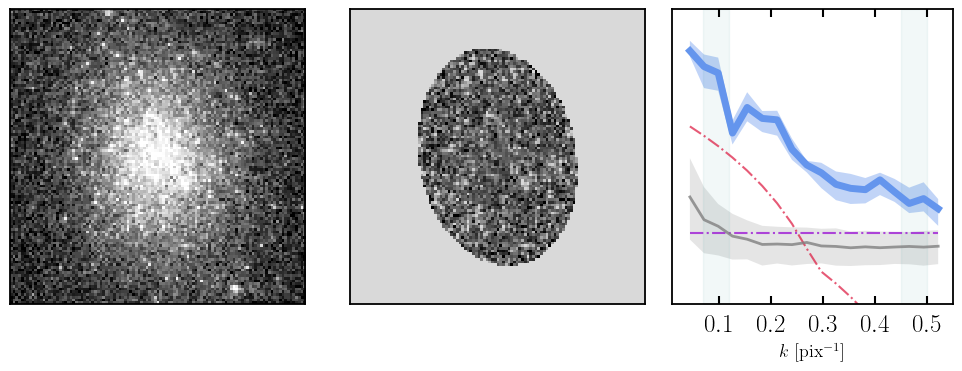

In [419]:
fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(results, sat, None, SNR, figsize=(12.5, 3.6),
                                         percu=99, percl=2, show_psf=True, show_noise=True, 
                                         show_KDE=True, reverse_cmap=True, show_bkgfit=False, show_fit=False)

Image shape: (215, 215)


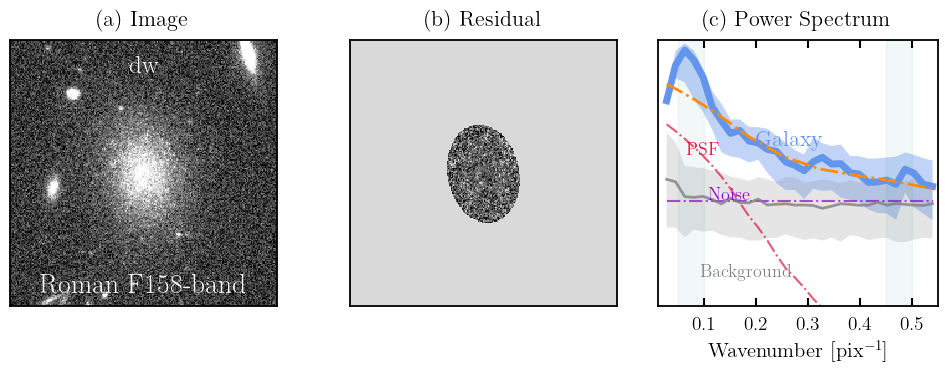

In [114]:
fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(results, sat, None, SNR, figsize=(12.5, 3.6),
                                         percu=99.1, percl=2, show_psf=True, show_noise=True, 
                                         show_KDE=True, reverse_cmap=True, show_bkgfit=False, show_fit=True)

ax1.set_aspect('equal', adjustable='box')
ax2.set_aspect('equal', adjustable='box')

ax1.text(0.5, 0.9, name.split('_')[0], color='w',
         fontsize=18, ha='center', va='center',
         transform=ax1.transAxes)

ax1.text(0.5, 0.08, f'Roman {sat.sbf_filt}-band', color='w',
         fontsize=20, ha='center', va='center',
         transform=ax1.transAxes, alpha=1)

# ax4.set_xticks([6, 7, 8, 9, 10, 11])
# ax4.set(xlim=[5.8, 11.2])

ax1.set_title("(a) Image", fontsize=16)
ax2.set_title("(b) Residual", fontsize=16)
ax3.set_title("(c) Power Spectrum", fontsize=16)
# ax4.set_title("(d) Distance", fontsize=16)

ax3.tick_params(axis='both', which='major', labelsize=14)
# ax4.tick_params(axis='both', which='major', labelsize=14)

ax3.text(0.1, 0.57, 'PSF', color='crimson', transform=ax3.transAxes, fontsize=13)
ax3.text(0.18, 0.4, 'Noise', color='darkviolet', transform=ax3.transAxes, fontsize=13)
ax3.text(0.35, 0.6, 'Galaxy', color='cornflowerblue', transform=ax3.transAxes, fontsize=16)
ax3.text(0.15, 0.11, 'Background', color='gray', transform=ax3.transAxes, fontsize=13)
ax3.set_xlabel('Wavenumber [pix$^{-1}$]', fontsize=15)
ax4.set_xlabel('Distance [Mpc]', fontsize=15)

ax3.set_aspect('auto')
# ax4.set_aspect('auto')

# ax1.text(0.05, 0.9, '(a)', color='w', fontsize=14, transform=ax1.transAxes)

# plt.subplots_adjust(wspace=0.0)
# plt.tight_layout()

# plt.savefig('/tigress/jiaxuanl/public_html/figure/SBF/Roman25/euclid_sbf_dw1906m6357.pdf', dpi=100)

In [ ]:
[left, bottom, width, height]

In [482]:
ax1_pos

Bbox([[0.125, 0.17812827093397732], [0.30751811594202905, 0.8118717290660227]])

In [485]:
ax1_pos.y1

0.8118717290660227

In [153]:
fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(results, sat, D_meas, SNR, 
                                         percu=98.6, percl=2, show_psf=True, show_noise=True, 
                                         show_KDE=True, reverse_cmap=True)
ax1.text(0.5, 0.9, name.split('_')[0], color='w', 
         fontsize=18, ha='center', va='center',
         transform=ax1.transAxes)

ax1.text(0.05, 0.11, f'RA={sat.ra} \n Dec=${sat.dec}$', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes,
         bbox=dict(facecolor='wheat', edgecolor='w', boxstyle='round', alpha=0.7))

# ax2.text(0.02, 0.05, 'Name: ' + name, color='k', 
#          fontsize=15, ha='left', va='center',
#          transform=ax2.transAxes)

ax2.text(0.05, 0.9, f'Euclid {sat.sbf_filt}-band', color=dict(i="green", r='red', VIS='darkviolet', H='w')[sat.sbf_filt],
         fontsize=16, ha='left', va='center',
         transform=ax2.transAxes, alpha=1)

ax4.set_xticks([6, 7, 8, 9, 10, 11])
ax4.set(xlim=[5.8, 11.2])

# ax1.text(0.92, 0.08, sat.followup, color='tomato', fontsize=16, ha='right', va='center', transform=ax1.transAxes)

# plt.savefig('/tigress/jiaxuanl/public_html/figure/SBF/Roman25/euclid_sbf_dw1906m6357.pdf', dpi=100)

NameError: name 'D_meas' is not defined

In [ ]:
plt.vlines()

Image shape: (215, 215)


KeyError: 'F158'

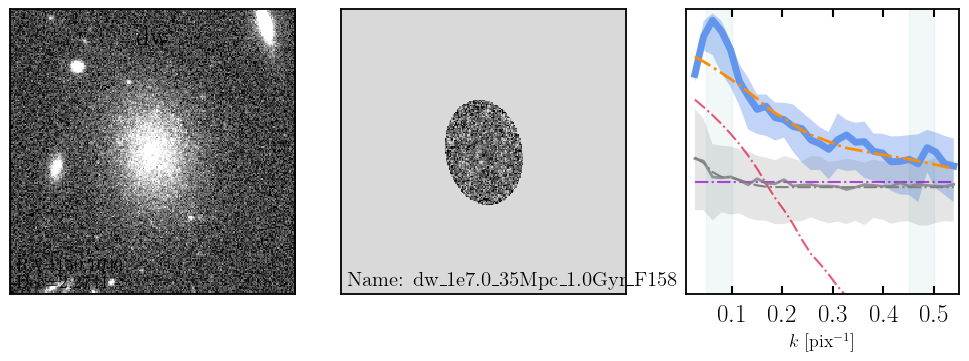

In [112]:
fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(results, sat, None, SNR, 
                                         percu=98.6, percl=2, show_psf=True, show_noise=True, reverse_cmap=True)
ax1.text(0.5, 0.9, name.split('_')[0], color='k', 
         fontsize=20, ha='center', va='center',
         transform=ax1.transAxes)
ax1.text(0.02, 0.10, f'RA={sat.ra}', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes)
ax1.text(0.02, 0.04, f'Dec=${sat.dec}$', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes)
ax2.text(0.02, 0.05, 'Name: ' + name, color='k', 
         fontsize=15, ha='left', va='center',
         transform=ax2.transAxes)
ax2.text(0.05, 0.9, f'{sat.sbf_filt}-band', color=dict(i="green", r='red', VIS='darkviolet', H='darkviolet')[sat.sbf_filt],
         fontsize=16, ha='left', va='center',
         transform=ax2.transAxes)

ax1.text(0.9, 0.08, sat.followup, color='red', fontsize=15, ha='right', va='center', transform=ax1.transAxes)

# plt.savefig('/tigress/jiaxuanl/public_html/figure/SBF/Roman25/euclid_sbf_dw1906m6357.pdf', dpi=100)

Image shape: (165, 165)
[6.8196724039532395, 7.549960000806478, 8.392162711285732, 9.318075991945243, 10.34976916265804]


Text(0.9, 0.08, 'Euclid')

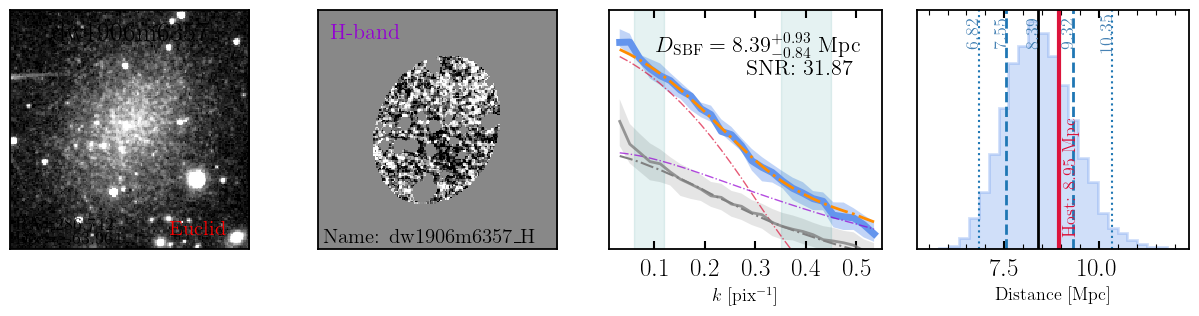

In [201]:
fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(results, sat, D_meas, SNR, 
                                         percu=98.6, percl=2, show_psf=True, show_noise=True, reverse_cmap=True)
ax1.text(0.5, 0.9, name.split('_')[0], color='k', 
         fontsize=20, ha='center', va='center',
         transform=ax1.transAxes)
ax1.text(0.02, 0.10, f'RA={sat.ra}', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes)
ax1.text(0.02, 0.04, f'Dec=${sat.dec}$', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes)
ax2.text(0.02, 0.05, 'Name: ' + name, color='k', 
         fontsize=15, ha='left', va='center',
         transform=ax2.transAxes)
ax2.text(0.05, 0.9, f'{sat.sbf_filt}-band', color=dict(i="green", r='red', VIS='darkviolet', H='darkviolet')[sat.sbf_filt],
         fontsize=16, ha='left', va='center',
         transform=ax2.transAxes)

ax1.text(0.9, 0.08, sat.followup, color='red', fontsize=15, ha='right', va='center', transform=ax1.transAxes)

# plt.savefig('/tigress/jiaxuanl/public_html/figure/SBF/Roman25/euclid_sbf_dw1906m6357.pdf', dpi=100)

Image shape: (143, 143)


Text(0.9, 0.75, 'SNR: 4.66')

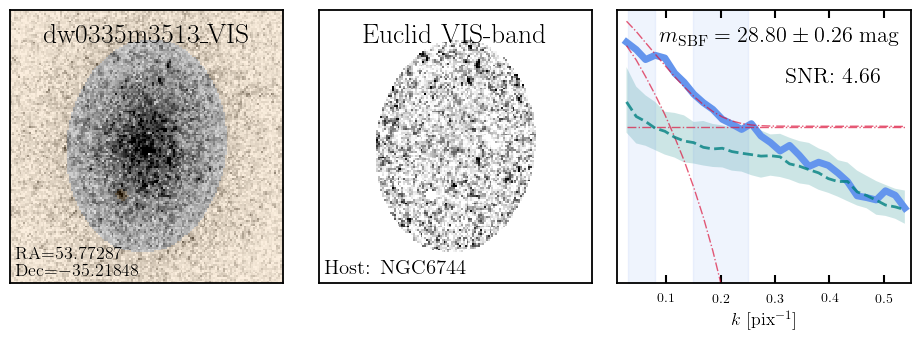

In [228]:
fig, [ax1, ax2, ax3, ax4] = plot_SBF_all(gal_sbfs, bkg_sbfs, img, f_model_real, sersic, sat, None, None, 
                                         percu=99.5, percl=5)

ax1.text(0.5, 0.9, name, color='k', 
         fontsize=20, ha='center', va='center',
         transform=ax1.transAxes)

ax1.text(0.02, 0.10, f'RA={sat.ra}', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes)
ax1.text(0.02, 0.04, f'Dec=${sat.dec}$', color='k', 
         fontsize=13, ha='left', va='center',
         transform=ax1.transAxes)

ax2.text(0.5, 0.9, f'Euclid {sat.sbf_filt}-band', color='k', 
         fontsize=20, ha='center', va='center',
         transform=ax2.transAxes)

ax2.text(0.02, 0.05, 'Host: ' + host_name, color='k', 
         fontsize=15, ha='left', va='center',
         transform=ax2.transAxes)

m_SBF = (-2.5 * np.log10(f_sbf_meas) + zp)
# m_SBF[np.isnan(m_SBF)] = np.inf
SNR = (np.nanmedian(f_sbf_meas) / np.nanstd(f_sbf_meas))
label = r'$m_{\rm SBF} =' + f'{np.nanmedian(m_SBF):.2f}' + '\pm' + f'{np.nanstd(m_SBF):.2f}' + r'\ \rm{mag}$'
ax3.text(0.55, 0.9, label, color='k', 
         fontsize=16, ha='center', va='center',
         transform=ax3.transAxes)
ax3.text(0.9, 0.75, f'SNR: {np.nanmedian(SNR):.2f}', ha='right', va='center', fontsize=16, transform=ax3.transAxes)

# plt.savefig(f'/tigress/jiaxuanl/public_html/figure/SALAD/{host_name}/{sat.name}_sbf.png')

----